In [1]:
from pathlib import Path
import h5py
import shutil
import json

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import rfft, rfftfreq

from modules import EMGPreprocessing, GloveDataPreprocessing, MarkupDataPreprocessing

DPI = plt.rcParams['figure.dpi']

In [2]:
initial_data_dir = Path('/home/matthew/datasets/EMG_glove')
file_name = '4.hdf5'

tmp_folder = Path('./tmp')
tmp_folder.mkdir(parents=True, exist_ok=True)

plots_folder = tmp_folder / 'plots' / file_name.split('.')[0]
plots_folder.mkdir(parents=True, exist_ok=True)

data_folder = tmp_folder / 'data' / file_name.split('.')[0]
data_folder.mkdir(parents=True, exist_ok=True)

---

DATA IS EXTRACTED
float32
(16414720, 128)


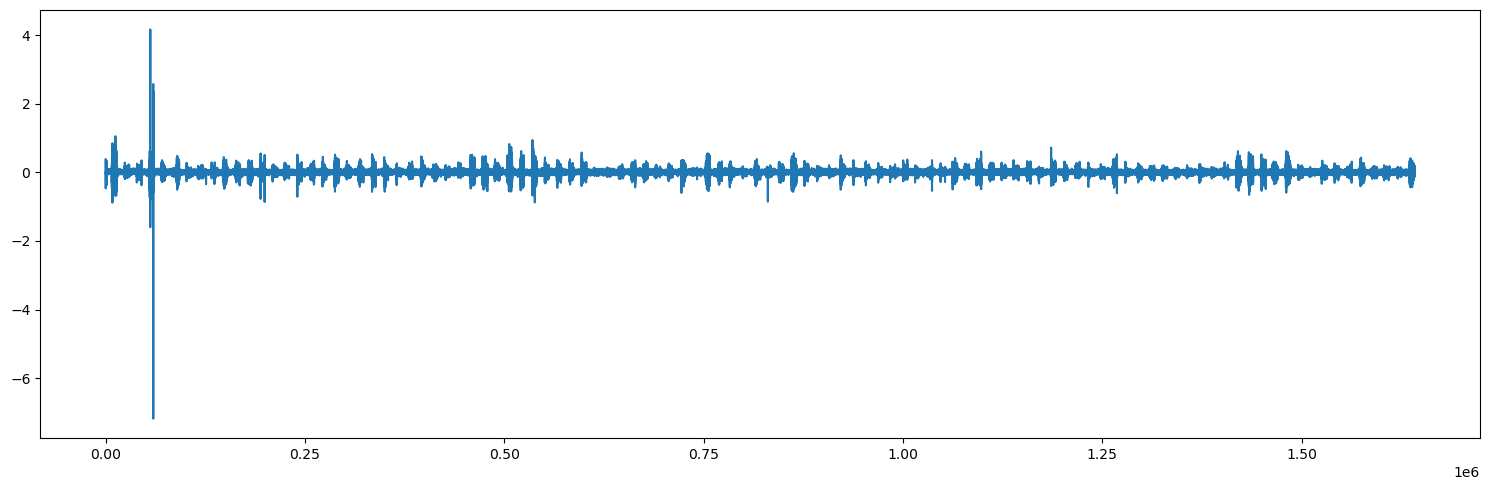

In [3]:
channels_slice = slice(64, 192)

emg_preprocesser = EMGPreprocessing(
    file_dir = initial_data_dir / file_name,
    channels_slice=channels_slice
)
emg_preprocesser()

In [4]:
markup_preprocesser = MarkupDataPreprocessing(initial_data_dir / file_name)
markup_preprocesser()

In [5]:
glove_preprocesser = GloveDataPreprocessing(
    file_dir=initial_data_dir / file_name,
    required_sampling_rate=1024
)
glove_preprocesser()

In [6]:
with h5py.File(data_folder / file_name, mode='w') as hdf_file:
    hdf_file.create_dataset('emg', data=emg_preprocesser.emg_data)
    hdf_file.create_dataset('markup', data=markup_preprocesser.exercises)
    hdf_file.create_dataset('repeats', data=markup_preprocesser.repeats)
    hdf_file.create_dataset('lia', data=glove_preprocesser.lia_data)
    hdf_file.create_dataset('fingers', data=glove_preprocesser.fingers_quaternions)
    hdf_file.create_dataset('bones', data=glove_preprocesser.bones_quaternions)

del emg_preprocesser, markup_preprocesser, glove_preprocesser

---

In [7]:
def envelope_signal(signal_data: NDArray, sampling_rate: int, low_threshold: float) -> NDArray:
    low_pass = low_threshold / (sampling_rate / 2)
    b, a = signal.butter(4, low_pass, btype='lowpass')
    return signal.filtfilt(b, a, signal_data)

def normalise_signal(signal_data: NDArray):
    return (signal_data - signal_data.min()) / signal_data.std()

def plot_two_signals(signal_1: NDArray, signal_2: NDArray, save_dir: None | Path = None):
    plt.close()
    fig, ax = plt.subplots(ncols=1, nrows=1)
    fig.set_size_inches(w=1500 / DPI, h=500 / DPI)
    ax.plot(signal_1)
    ax.plot(signal_2)
    fig.tight_layout()
    if save_dir:
        plt.savefig(save_dir)    
    else:
        plt.show()
    

def _zscore_1d(x, eps=1e-12):
    """
    Робастно нормирует одномерный фрагмент для корреляции.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    std = np.std(x)

    if std < eps:
        return np.zeros_like(x)

    return x / std


def _normalized_correlation(x, y, normalize=True):
    """
    Считает корреляционное сходство двух фрагментов одинаковой длины.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x и y должны иметь одинаковую длину.")

    if normalize:
        x = _zscore_1d(x)
        y = _zscore_1d(y)

    return float(np.sum(x * y))


def windowed_sync_indices_by_cross_correlation(
    reference_signal,
    movable_signal,
    window_size,
    step_size=None,
    max_shift=None,
    normalize=True,
    drop_incomplete=True,
    use_previous_shift=False,
    return_info=False
):
    """
    Оконная синхронизация двух одномерных сигналов через локальную корреляцию.

    Первый сигнал считается эталонным.
    Второй сигнал считается движемым.

    Для каждого окна первого сигнала функция ищет наиболее похожее окно
    во втором сигнале около ожидаемой позиции.

    Parameters
    ----------
    reference_signal : array-like
        Эталонный сигнал.

    movable_signal : array-like
        Движемый сигнал. Для него возвращаются индексы.

    window_size : int
        Размер окна в отсчётах.

    step_size : int or None
        Шаг окна в отсчётах.
        Если None, окна идут без перекрытия: step_size = window_size.

    max_shift : int or None
        Максимальный локальный сдвиг второго окна относительно первого окна.

        Например:
        max_shift = 200 означает, что для окна первого сигнала
        [start, start + window_size] будут проверяться окна второго сигнала
        со стартами от start - 200 до start + 200.

        Если None, max_shift = window_size // 2.

    normalize : bool
        Если True, каждое окно нормируется перед корреляцией.

    drop_incomplete : bool
        Если True, неполные окна в конце отбрасываются.

    use_previous_shift : bool
        Если True, ожидаемая позиция следующего окна во втором сигнале
        корректируется с учётом сдвига, найденного на предыдущем окне.
        Это полезно при плавном дрейфе синхронизации.

    return_info : bool
        Если True, возвращает дополнительную информацию по каждому окну.

    Returns
    -------
    movable_indices : list[int]
        Индексы второго сигнала.

    info : dict, optional
        Диагностическая информация.
    """

    reference_signal = np.asarray(reference_signal, dtype=float)
    movable_signal = np.asarray(movable_signal, dtype=float)

    if reference_signal.ndim != 1:
        raise ValueError("reference_signal должен быть одномерным.")

    if movable_signal.ndim != 1:
        raise ValueError("movable_signal должен быть одномерным.")

    if window_size <= 1:
        raise ValueError("window_size должен быть больше 1.")

    if step_size is None:
        step_size = window_size

    if step_size <= 0:
        raise ValueError("step_size должен быть положительным.")

    if max_shift is None:
        max_shift = window_size // 2

    max_shift = int(max_shift)

    n_ref = len(reference_signal)
    n_mov = len(movable_signal)

    movable_indices = []

    reference_windows = []
    movable_windows = []
    shifts = []
    correlations = []
    skipped_windows = []

    previous_shift = 0

    if drop_incomplete:
        ref_starts = range(0, n_ref - window_size + 1, step_size)
    else:
        ref_starts = range(0, n_ref, step_size)

    for ref_start in ref_starts:
        ref_end = ref_start + window_size

        if ref_end > n_ref:
            if drop_incomplete:
                break
            ref_end = n_ref

        current_window_size = ref_end - ref_start

        if current_window_size < 2:
            skipped_windows.append({
                "reference_window": (ref_start, ref_end),
                "reason": "reference window too short"
            })
            continue

        ref_window = reference_signal[ref_start:ref_end]

        # Ожидаемая позиция во втором сигнале
        if use_previous_shift:
            expected_mov_start = ref_start + previous_shift
        else:
            expected_mov_start = ref_start

        candidate_start_min = expected_mov_start - max_shift
        candidate_start_max = expected_mov_start + max_shift

        # Ограничение границами второго сигнала
        candidate_start_min = max(0, candidate_start_min)
        candidate_start_max = min(
            n_mov - current_window_size,
            candidate_start_max
        )

        if candidate_start_max < candidate_start_min:
            skipped_windows.append({
                "reference_window": (ref_start, ref_end),
                "reason": "no valid candidate windows"
            })
            continue

        best_corr = -np.inf
        best_mov_start = None

        for mov_start in range(candidate_start_min, candidate_start_max + 1):
            mov_end = mov_start + current_window_size
            mov_window = movable_signal[mov_start:mov_end]

            corr = _normalized_correlation(
                ref_window,
                mov_window,
                normalize=normalize
            )

            if corr > best_corr:
                best_corr = corr
                best_mov_start = mov_start

        best_mov_end = best_mov_start + current_window_size
        best_shift = best_mov_start - ref_start

        previous_shift = best_shift

        movable_indices.extend(range(best_mov_start, best_mov_end))

        reference_windows.append((ref_start, ref_end))
        movable_windows.append((best_mov_start, best_mov_end))
        shifts.append(best_shift)
        correlations.append(best_corr)

    if return_info:
        info = {
            "reference_windows": reference_windows,
            "movable_windows": movable_windows,
            "shifts": shifts,
            "correlations": correlations,
            "skipped_windows": skipped_windows
        }

        return movable_indices, info

    return movable_indices

In [9]:
channel_data = None
lia_data = None

with h5py.File(data_folder / file_name, mode='r') as hdf_file:
    channel_data = envelope_signal(normalise_signal(np.abs(hdf_file.get('emg')[:, 127])), sampling_rate=1024, low_threshold=5)
    lia_data = envelope_signal(normalise_signal(hdf_file.get('lia')[:]), sampling_rate=1024, low_threshold=5)

In [15]:
emg_glove_synchronisation_indeces = windowed_sync_indices_by_cross_correlation(
    reference_signal=channel_data,
    movable_signal=lia_data,
    window_size=1024*30,
    max_shift=512,
    use_previous_shift=True
)

with open(data_folder / 'emg_glove_indeces.json', mode='w') as json_file:
    json.dump(emg_glove_synchronisation_indeces, json_file)

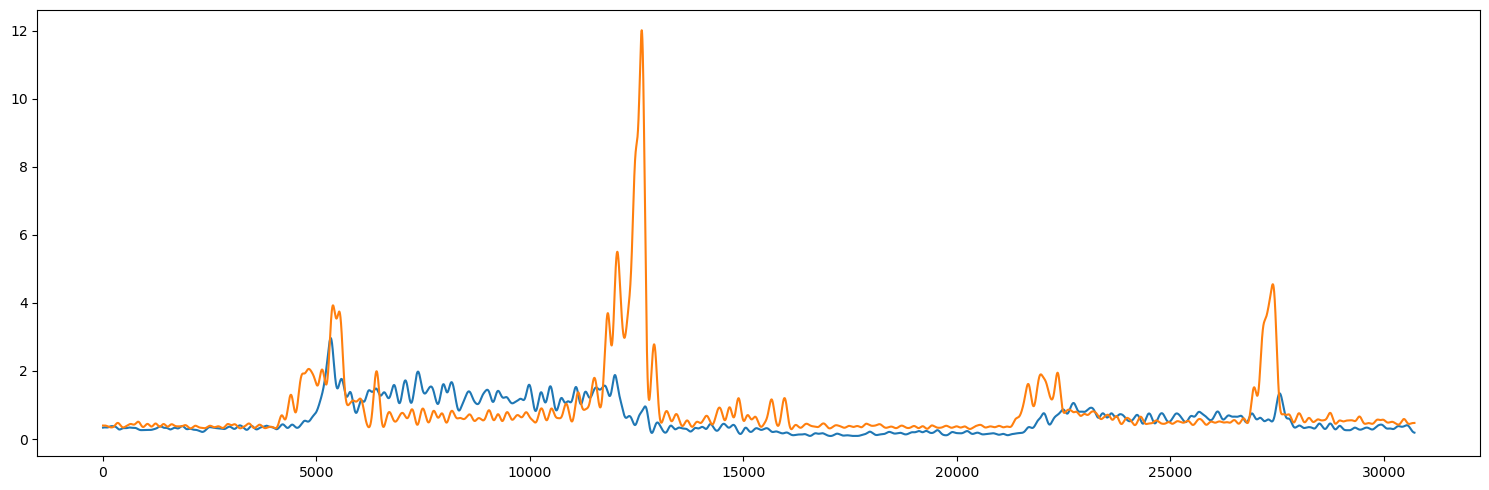

In [16]:
sync_plots_folder = plots_folder / 'sync_emg_lia'
sync_plots_folder.mkdir(parents=True, exist_ok=True)

sampling_rate = 1024
window_width = 30 * sampling_rate
for window_idx in range(len(emg_glove_synchronisation_indeces) // window_width):
    plot_two_signals(
        channel_data[window_idx * window_width: (window_idx + 1) * window_width],
        lia_data[emg_glove_synchronisation_indeces][window_idx * window_width: (window_idx + 1) * window_width],
        save_dir=sync_plots_folder / f'{window_idx}.png'
    )

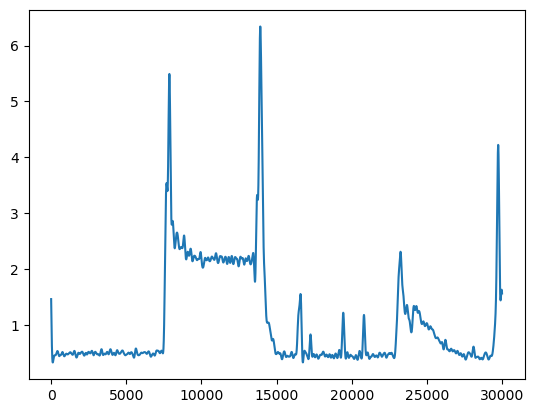

In [18]:
plt.plot(lia_data[emg_glove_synchronisation_indeces][:30000])